In [35]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
df = sns.load_dataset("titanic")

In [38]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [40]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [41]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [42]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [43]:
df.shape

(891, 15)

In [44]:
df.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [45]:
df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

df = df.drop(columns=["deck"])

In [46]:
df.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

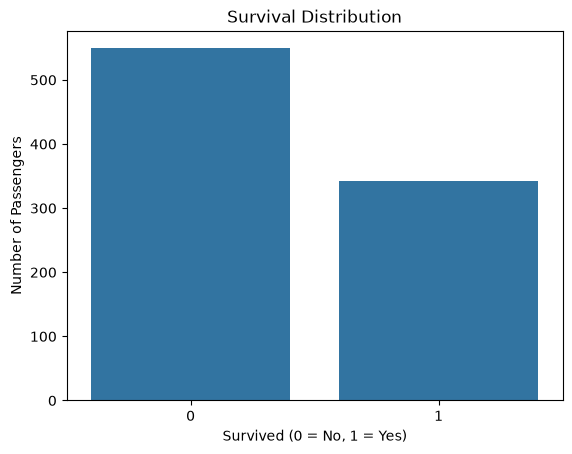

In [47]:
sns.countplot(x="survived", data=df)
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

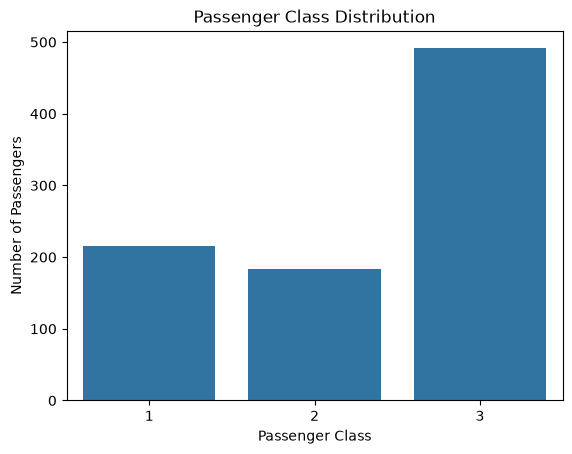

In [48]:
sns.countplot(x="pclass", data=df)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

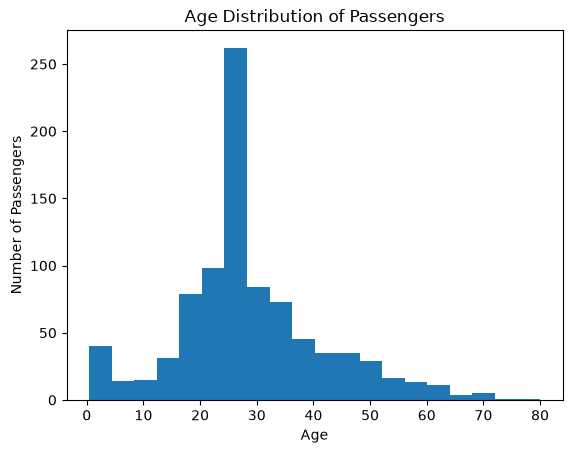

In [49]:
plt.hist(df["age"], bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

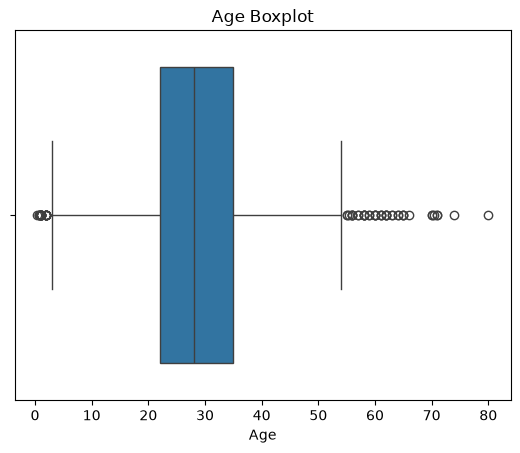

In [50]:
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.show()

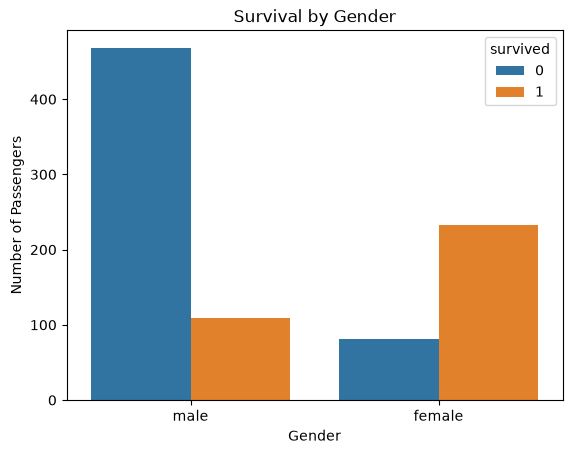

In [51]:
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

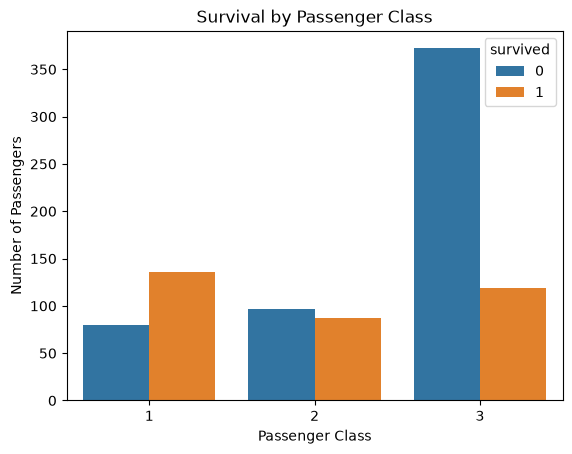

In [52]:
sns.countplot(x="pclass", hue="survived", data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

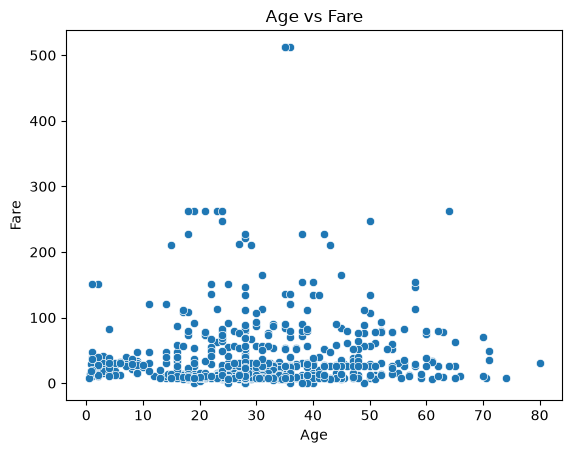

In [53]:
sns.scatterplot(x="age", y="fare", data=df)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


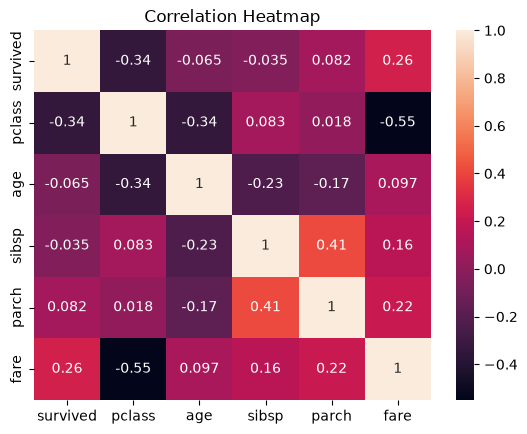

In [54]:
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

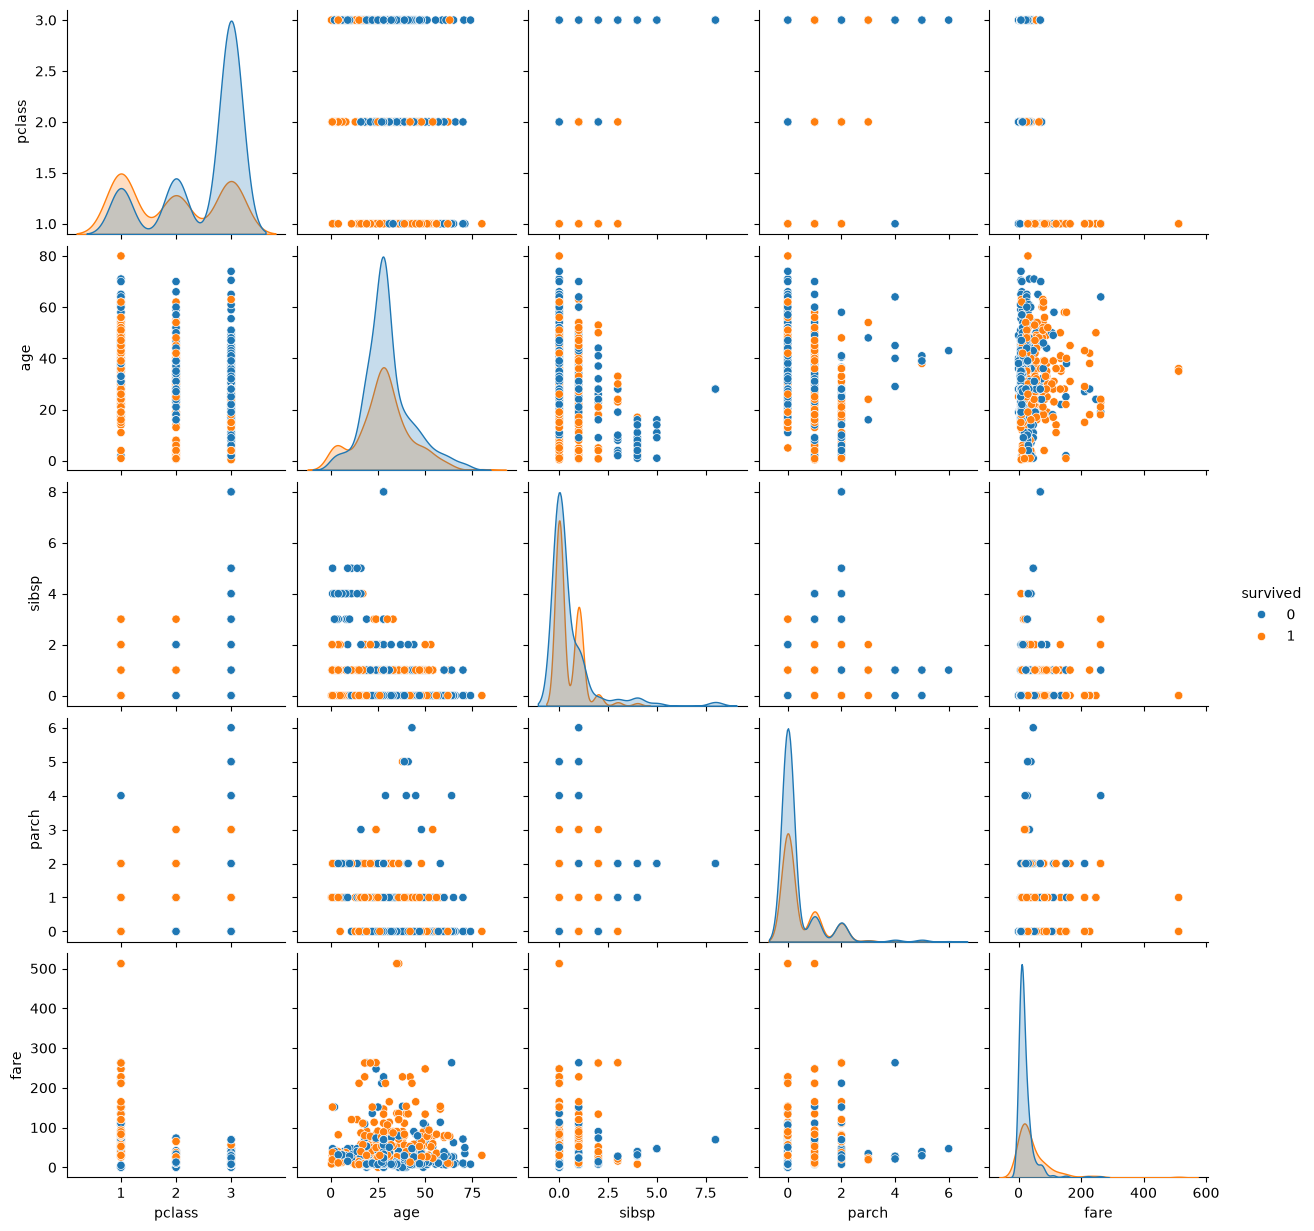

In [55]:
sns.pairplot(
    df[["survived", "pclass", "age", "sibsp", "parch", "fare"]],
    hue="survived"
)
plt.show()

## 📊 Observations

### 1. Survival Distribution
The number of passengers who did not survive was higher than the number of passengers who survived.

### 2. Passenger Class Distribution
Third-class passengers formed the largest group of passengers, followed by first-class and second-class passengers.

### 3. Age Distribution
Most passengers were adults, while fewer passengers were children and older adults.

### 4. Age Boxplot
The boxplot shows the distribution and spread of passenger ages and highlights some higher-age values as potential outliers.

### 5. Survival by Gender
Female passengers had a higher survival rate compared with male passengers.

### 6. Survival by Passenger Class
First-class passengers generally had better survival outcomes than second- and third-class passengers.

### 7. Age vs Fare
The scatterplot shows that passenger fare varies considerably across different ages, with some passengers paying much higher fares.

### 8. Correlation Heatmap
The heatmap shows relationships between the numerical variables. Passenger class and fare show a noticeable relationship with survival.

### 9. Pairplot
The pairplot provides an overall view of relationships among the numerical variables and shows differences between survived and non-survived passengers.

## 📝 Summary of Findings

The Exploratory Data Analysis of the Titanic dataset revealed several important patterns.

Survival was not evenly distributed among passengers. Gender and passenger class showed noticeable differences in survival outcomes. Female passengers generally had better survival outcomes than male passengers, while first-class passengers generally had better survival outcomes than passengers in lower classes.

The analysis also showed variation in passenger ages and fares. The correlation heatmap and pairplot helped identify relationships among the numerical variables.

Overall, EDA helped identify important patterns, relationships, and possible outliers in the Titanic dataset.